# 데이터 불러오기

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import scipy.stats as stats

In [3]:
df = pd.read_csv('./data_for_eda/telecom_encoding.csv')
df.head()

,id,gender,age,year,school,income,job,phone_usage_per_m,telecom_change_yn,mobile_bundle,...,jeonbuk,jeonnam,gyeongbuk,gyeongnam,jeju,sejong,skt,kt,lgu,mvno
0,10002,1,45,2017,4,0,0,29,0,0,...,0,0,0,0,0,0,1,0,0,0
1,10002,1,46,2018,4,0,0,35,0,1,...,0,0,0,0,0,0,1,0,0,0
2,10002,1,47,2019,4,0,0,58,0,1,...,0,0,0,0,0,0,1,0,0,0
3,10002,1,48,2020,4,0,0,37,1,1,...,0,0,0,0,0,0,0,1,0,0
4,10002,1,49,2021,4,0,0,32,0,1,...,0,0,0,0,0,0,0,1,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31572 entries, 0 to 31571
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 31572 non-null  int64
 1   gender             31572 non-null  int64
 2   age                31572 non-null  int64
 3   year               31572 non-null  int64
 4   school             31572 non-null  int64
 5   income             31572 non-null  int64
 6   job                31572 non-null  int64
 7   phone_usage_per_m  31572 non-null  int64
 8   telecom_change_yn  31572 non-null  int64
 9   mobile_bundle      31572 non-null  int64
 10  mar_1              31572 non-null  int64
 11  mar_2              31572 non-null  int64
 12  mar_3              31572 non-null  int64
 13  mar_4              31572 non-null  int64
 14  seoul              31572 non-null  int64
 15  busan              31572 non-null  int64
 16  daegu              31572 non-null  int64
 17  incheon     

# 1. 고객 특성별 이탈(Churn) 분석

### 1-1. 연령대별 이탈률

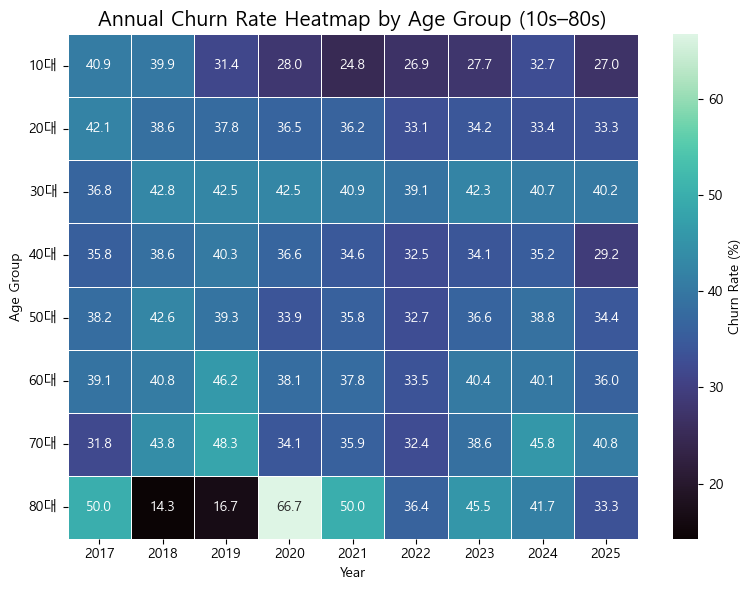

In [16]:
plt.rc('font', family='Malgun Gothic') # For Windows

# 1. 10살 단위 연령대 생성
df['age_group'] = (df['age'] // 10) * 10
df['age_group_name'] = df['age_group'].astype(int).astype(str) + '대'

# 2. 10대~80대 필터
df = df[(df['age_group'] >= 10) & (df['age_group'] <= 80)]

# 3. 연도별 & 연령대별 이탈률 계산
annual_age_churn = (
    df.groupby(['year', 'age_group_name'])['telecom_change_yn']
    .mean()
    .reset_index()
)

annual_age_churn['churn_rate_pct'] = annual_age_churn['telecom_change_yn'] * 100

# 4. 연령대 순서 정렬용 카테고리 설정
age_order = [f"{i}대" for i in range(10, 90, 10)]
annual_age_churn['age_group_name'] = pd.Categorical(
    annual_age_churn['age_group_name'],
    categories=age_order,
    ordered=True
)

# 5. 피벗
heatmap_data = annual_age_churn.pivot(
    index='age_group_name',
    columns='year',
    values='churn_rate_pct'
)

# 6. 히트맵
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=.5,
    cbar_kws={'label': 'Churn Rate (%)'}
)

plt.title('Annual Churn Rate Heatmap by Age Group (10s–80s)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Age Group')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 1-2. 소득 수준에 따른 이탈률

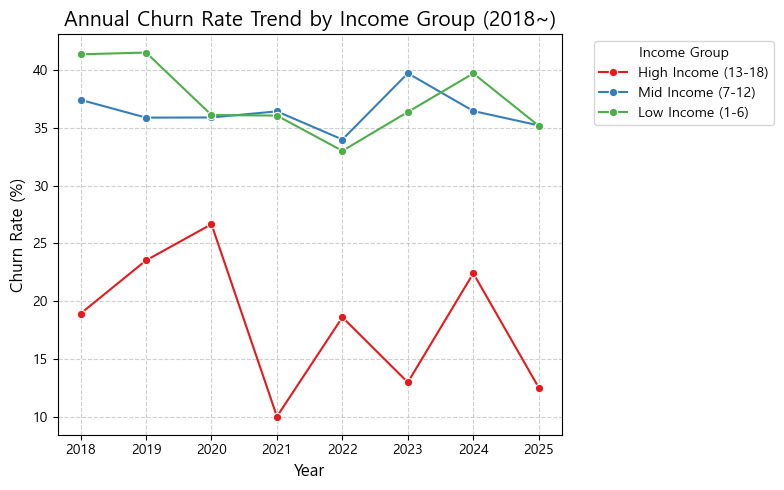

In [17]:
df = df[df['year'] >= 2018].copy()
df['income'] = df['income'].astype(int)

# 1. 소득 구간화 (1~18을 3등분)
def categorize_income(x):
    if x <= 6: 
        return 'Low Income (1-6)'
    elif x <= 12: 
        return 'Mid Income (7-12)'
    else: 
        return 'High Income (13-18)'

df['income_group'] = df['income'].apply(categorize_income)

# 2. 연도별 & 소득 구간별 이탈률 계산
annual_income_churn = df.groupby(['year', 'income_group'])['telecom_change_yn'].mean().reset_index()
annual_income_churn['churn_rate_pct'] = annual_income_churn['telecom_change_yn'] * 100

# 3. 시각화 (선 그래프)
plt.figure(figsize=(8, 5))

# 범례 순서 지정
hue_order = ['High Income (13-18)', 'Mid Income (7-12)', 'Low Income (1-6)']
sns.lineplot(data=annual_income_churn, x='year', y='churn_rate_pct', hue='income_group', 
            hue_order=hue_order, marker='o', palette='Set1')

plt.title('Annual Churn Rate Trend by Income Group (2018~)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 밖으로
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # 그래프가 잘리지 않게 조정

plt.show()

### 1-4. 결합 상품 유무에 따른 이탈

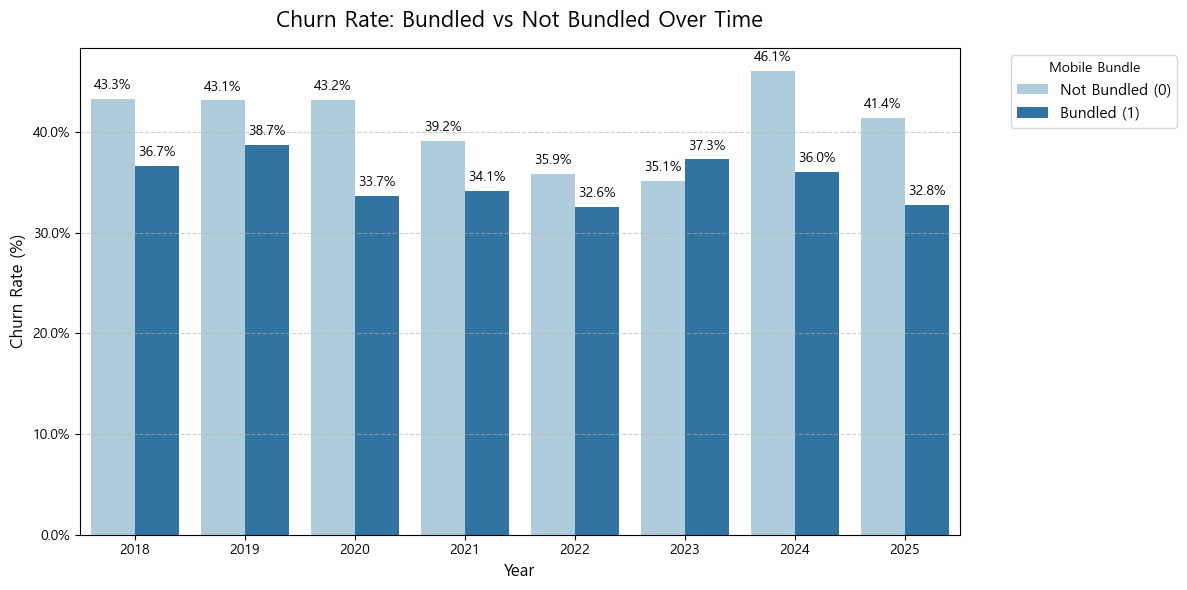

In [24]:
from matplotlib.ticker import PercentFormatter

# 2. 가독성을 위해 결합 상품 값을 문자열로 변환 (0: 미결합, 1: 결합)
df['Bundle_Status'] = df['mobile_bundle'].map({0: 'Not Bundled (0)', 1: 'Bundled (1)'})

# 3. 연도별 & 결합 유무별 이탈률 계산
bundle_churn = df.groupby(['year', 'Bundle_Status'])['telecom_change_yn'].mean().reset_index()

# 4. 시각화 (그룹 막대 그래프)
plt.figure(figsize=(12, 6))

# 막대 그래프 생성
ax = sns.barplot(data=bundle_churn, x='year', y='telecom_change_yn', 
                 hue='Bundle_Status', hue_order=['Not Bundled (0)', 'Bundled (1)'], palette="Paired")

# Y축을 퍼센트(%) 포맷으로 변경
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# 그래프 꾸미기
plt.title('Churn Rate: Bundled vs Not Bundled Over Time', fontsize=16, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.legend(title='Mobile Bundle', fontsize=11, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# 막대 위에 정확한 퍼센트 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0: # 값이 있는 경우만 텍스트 표시
        ax.annotate(f'{height*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

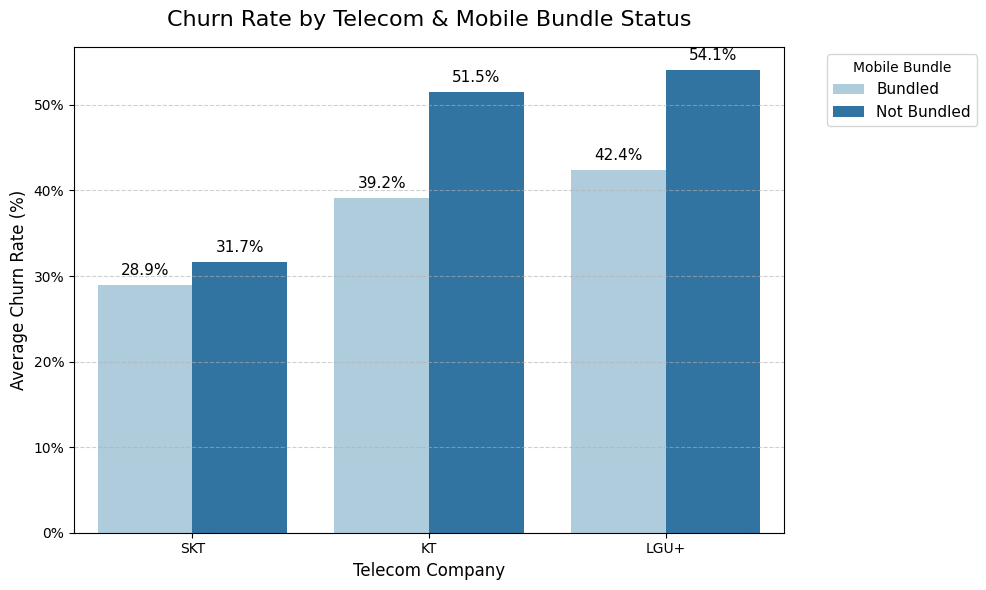

In [29]:
# 2. 가독성을 위해 데이터 매핑
# 통신사 이름 매핑 (1: SKT, 2: KT, 3: LGU+ 가정)
telecom_mapping = {1: 'SKT', 2: 'KT', 3: 'LGU+'}
df['Telecom_Name'] = df['telecom'].map(telecom_mapping)

# 결합 상품 이름 매핑
df['Bundle_Status'] = df['mobile_bundle'].map({0: 'Not Bundled', 1: 'Bundled'})

# 3. 통신사별 & 결합 유무별 이탈률 계산
telecom_bundle_churn = df.groupby(['Telecom_Name', 'Bundle_Status'])['telcom_changed'].mean().reset_index()

# 4. 시각화 (그룹 막대 그래프)
plt.figure(figsize=(10, 6))

# 막대 그래프 생성
ax = sns.barplot(data=telecom_bundle_churn, x='Telecom_Name', y='telcom_changed', 
                 hue='Bundle_Status', palette="Paired",
                 order=['SKT', 'KT', 'LGU+']) # 통신사 순서 고정

# Y축을 퍼센트(%) 포맷으로 변경
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# 그래프 꾸미기
plt.title('Churn Rate by Telecom & Mobile Bundle Status', fontsize=16, pad=15)
plt.xlabel('Telecom Company', fontsize=12)
plt.ylabel('Average Churn Rate (%)', fontsize=12)
plt.legend(title='Mobile Bundle', fontsize=11, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# 막대 위에 정확한 퍼센트 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height*100:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

### 1-3. Sanky Diagram

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# 1. Source(과거 통신사)와 Target(현재 통신사) 추출 함수
def get_source_target(status):
    if '_to_' in status:  
        source, target = status.split('_to_')
        return source, target
    elif '_Stay' in status:  
        comp = status.split('_')[0]
        return comp, comp
    return None, None

# 3. 새로운 컬럼에 Source, Target 할당
df['source'], df['target'] = zip(*df['churn_status_1'].apply(get_source_target))
df = df.dropna(subset=['source', 'target'])

# 4. 과거와 현재 꼬리표 붙이기
df['source_label'] = df['source'] + ' (과거)'
df['target_label'] = df['target'] + ' (현재)'

# 5. 빈도수 집계
flow_counts = df.groupby(['source_label', 'target_label']).size().reset_index(name='count')

# 6. 인덱스 매핑
all_nodes = list(pd.concat([flow_counts['source_label'], flow_counts['target_label']]).unique())
node_dict = {node: i for i, node in enumerate(all_nodes)}

flow_counts['source_idx'] = flow_counts['source_label'].map(node_dict)
flow_counts['target_idx'] = flow_counts['target_label'].map(node_dict)

# 7. 색상 대폭 수정 (파스텔 톤 & 밝게)
node_colors = []
for node in all_nodes:
    if 'SKT' in node: node_colors.append('rgba(255, 153, 153, 0.9)')   # 파스텔 레드
    elif 'KT' in node: node_colors.append('rgba(153, 204, 255, 0.9)')  # 파스텔 블루
    elif 'LGU' in node: node_colors.append('rgba(255, 204, 153, 0.9)') # 파스텔 오렌지
    else: node_colors.append('rgba(220, 220, 220, 0.9)')

link_colors = []
for _, row in flow_counts.iterrows():
    source_base = row['source_label'].replace(' (과거)', '')
    target_base = row['target_label'].replace(' (현재)', '')
    
    if source_base == target_base:
        # 그대로 남는(Stay) 물줄기는 아주 연하고 투명한 회색으로 처리 (시선 분산 방지)
        link_colors.append('rgba(245, 245, 245, 0.5)') 
    else:
        # 이동하는(Churn) 물줄기만 출발지 색상으로 은은하게 강조
        if 'SKT' in source_base: link_colors.append('rgba(255, 153, 153, 0.5)')
        elif 'KT' in source_base: link_colors.append('rgba(153, 204, 255, 0.5)')
        elif 'LGU' in source_base: link_colors.append('rgba(255, 204, 153, 0.5)')
        else: link_colors.append('rgba(220, 220, 220, 0.4)')

# 8. Sankey Diagram 생성 (검은 테두리 제거)
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 30,
      thickness = 25,
      # line 속성에서 검은색(black) 테두리를 완전히 없애고 투명하게 처리했습니다.
      line = dict(color = "rgba(255,255,255,0)", width = 0), 
      label = all_nodes,
      color = node_colors
    ),
    link = dict(
      source = flow_counts['source_idx'], 
      target = flow_counts['target_idx'],
      value = flow_counts['count'],
      color = link_colors
    )
)])

fig.update_layout(
    title_text="통신사 가입자 이동 흐름도 (Sankey Diagram - Light Version)", 
    font_size=14,
    height=600,
    plot_bgcolor='white', # 배경을 완전한 흰색으로
    paper_bgcolor='white'
)

fig.show()

# 2. 상관분석

In [ ]:
# 1. 분석할 범주형 변수 목록 설정 (연도나 ID, 이미 만들어진 파생변수 등은 제외)
categorical_features = ['gender', 'mar', 'income', 'job', 'region', 'phone_usage_per_m', 'mobile_bundle', 'telecom']
target = 'telcom_changed'

In [40]:
# 3. 크래머의 V (Cramér's V) 계산 함수 정의
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # 편향 보정 (Bias correction)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [41]:
# 4. 각 변수별로 p-value와 Cramér's V 계산
results = []
for col in categorical_features:
    # 결측치 제거 후 계산
    valid_data = df[[col, target]].dropna()
    
    # 카이제곱 검정 p-value
    contingency_table = pd.crosstab(valid_data[col], valid_data[target])
    p_value = stats.chi2_contingency(contingency_table)[1]
    
    # 크래머의 V 계산
    cv_score = cramers_v(valid_data[col], valid_data[target])
    
    results.append({'Feature': col, 'P-value': p_value, 'Cramers_V': cv_score})

# 결과 데이터프레임 생성 및 Cramér's V 기준으로 내림차순 정렬
results_df = pd.DataFrame(results).sort_values(by='Cramers_V', ascending=False)

In [43]:
# 텍스트로 결과 표 출력
print("=== 통계 분석 결과 (상관관계 높은 순) ===")
print(results_df.to_string(index=False))

=== 통계 분석 결과 (상관관계 높은 순) ===
          Feature       P-value  Cramers_V
           region 3.020627e-204   0.179117
          telecom 1.738289e-150   0.149734
           income  4.438883e-23   0.065281
phone_usage_per_m  4.303889e-25   0.064852
    mobile_bundle  2.290516e-29   0.063752
              mar  1.452668e-02   0.015616
              job  8.774394e-01   0.000000
           gender  5.502943e-01   0.000000
